In [1]:
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np
import os
import scipy
import pickle

from neurolib.models.aln import ALNModel
from neurolib.models.rate_control import RateModel
import neurolib.utils.functions as func
from neurolib.utils import costFunctions as cost
from neurolib.utils import plotFunctions as plotFunc

plt.rcParams['image.cmap'] = 'plasma'
cpalette = sns.color_palette('plasma')
np.set_printoptions(precision=6)

font = {
    'family' : 'sans',
    'weight' : 'normal',
    'size'   : 14
       }

matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=16) 
matplotlib.rc('ytick', labelsize=16) 
matplotlib.rc('grid', c='0.5', ls='-', lw=0.5)  # solid gray grid lines
matplotlib.rc('savefig', dpi=300)       # higher res outputs
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

path = os.getcwd()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
def step_control(maxI_ = 1.):
    control_ = aln.getZeroControl()
    for i_time in range(control_.shape[2]):
        if ( float(i_time/control_.shape[2]) < 0.1):
            control_[:,:2,i_time] = - maxI_
        elif ( float(i_time/control_.shape[2]) > 0.5 and float(i_time/control_.shape[2]) < 0.6 ):
            control_[:,:2,i_time] = maxI_
    return control_

In [3]:
def setinitvars(vars):
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                if aln.params[init_vars[iv]].ndim == 2:
                    aln.params[init_vars[iv]][0,:] = vars[sv]
                else:
                    aln.params[init_vars[iv]][:] = vars[sv]
                    

In [4]:
tol = 1e-32

c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

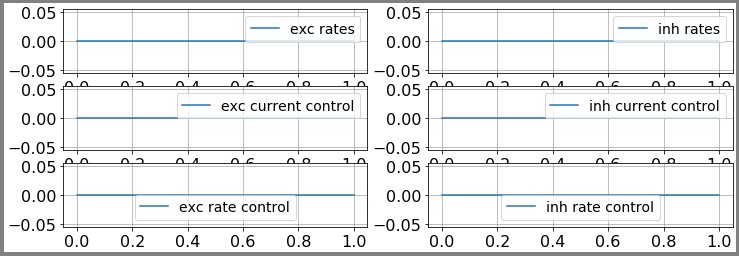

In [89]:
aln = RateModel()

aln.params['duration'] = 1.
aln.params.dt = 0.1
control0 = aln.getZeroControl()

# NO ADAPTATION
aln.params.IA_init = np.array([0.])
aln.params.a = 0.
aln.params.b = 0.

# no noise
aln.params.sigma_ou = 0.
aln.params.mue_ext_mean = 0.
aln.params.mui_ext_mean = 0.
aln.params.sigmae_ext = 0.
aln.params.sigmai_ext = 0.
aln.params.ext_exc_current = 0.
aln.params.ext_inh_current = 0.

# no delay
aln.params.signalV = 0.
aln.params.de = 0.
aln.params.di = 0.

aln.params.cie = 1.
aln.params.Jie_max = 1.
aln.params.tau_se = 1.
aln.params.tau_si = 1.
aln.params.C = 1.
aln.params.gL = 1.
aln.params.Ke = 1000.
aln.params.Ki = 1000.

plotFunc.plot_traces(aln, control0)

output = aln.output_vars

state_vars = aln.state_vars
init_vars = aln.init_vars

high_state_vars = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    if aln.state[state_vars[i]].size == 1:
        high_state_vars[i] = aln.state[state_vars[i]][0]
    else:
        high_state_vars[i] = aln.state[state_vars[i]][0,-2]

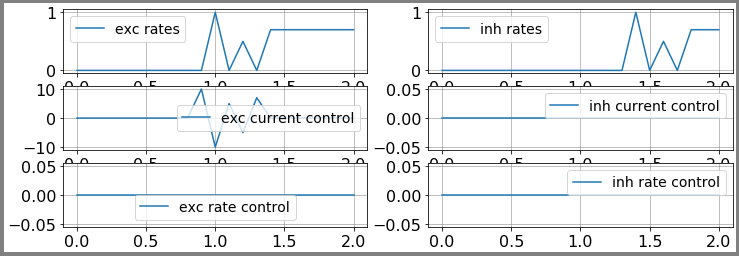

delay : 
exc rates :  [0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  1.  0.  0.5 0.  0.7 0.7 0.7 0.7
 0.7 0.7 0.7]
inh rates :  [0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  1.  0.  0.5 0.
 0.7 0.7 0.7]
[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]
[[[0.  0.  1.  0.  0.5 0.  0.7 0.7 0.7 0.7 0.7 0.7 0.7]
  [0.  0.  0.  0.  0.  0.  1.  0.  0.5 0.  0.7 0.7 0.7]]]


In [93]:
dur = 1.2
dur_pre = 0.8
dur_post = 0.8

n_dur = int(dur/aln.params.dt + 1)
n_pre = int(dur_pre/aln.params.dt + 1)

aln.params.duration = dur + dur_pre

control_ind = [0]
prec_var = [1]

if control_ind[0] == 0 or control_ind[0] == 1:
    max_cntrl = 10.
    min_cntrl = -10.
else:
    max_cntrl = 0.5
    min_cntrl = 0.

control0 = aln.getZeroControl()
#control0[0,control_ind,:] =  np.sin(np.arange(0,dur+1, 1))
#control0[0,control_ind,0] = 1.
for j in control_ind:
    control0[0,j,n_pre] =  max_cntrl #+ 0.5 * j * min_cntrl
    control0[0,j,n_pre + 1] =  min_cntrl
    control0[0,j,n_pre + 2] = 0.5*max_cntrl
    control0[0,j,n_pre + 3] = -0.5*max_cntrl
    control0[0,j,n_pre + 4] = 0.7*max_cntrl
    #control0[0,j,n_pre + 5] = -0.3*max_cntrl
    #control0[0,j,n_pre + 6] = 0.5*max_cntrl

setinitvars(high_state_vars)
aln.params.de = 0.3
plotFunc.plot_traces(aln, control0)
print("delay : ")
print("exc rates : ", aln.rates_exc[0,:])
print("inh rates : ", aln.rates_inh[0,:])

aln.params.duration = dur
target = aln.getZeroTarget()
target[0,0,:] = aln.rates_exc[0,n_pre-1:]
target[0,1,:] = aln.rates_inh[0,n_pre-1:]

print(aln.state["siev"])
print(target)

In [100]:
costparams = [1. * 1e0, 1.* 1e-2, 0.* 1e-2]
cost.setParams(costparams[0], costparams[1], costparams[2])

setinitvars(high_state_vars)
max_it = 1000
start_step = 1.
alg = "A1"
case = "test"

aln.params.duration = dur
control1 = aln.getZeroControl()
#control1[0,0,1] = 4.344642
#control2 = bestControlA
#control2 = bestControlA[:,:,n_pre-1:-n_pre+1]
#control2[0,0,4:] = 0.

# "HS", "FR", "PR", "HZ"
cgv = None

bestControlA, bestStateA, costA, runtimeA, grad = aln.A1(control1, target, c_scheme, u_mat, u_scheme,
        max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl, 
        min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post,
        CGVar = cgv, control_variables_ = control_ind, prec_variables_ = prec_var)

for j in control_ind:
    print("control ind ", j )
    print("grad = ", grad[0,j,:])
    print("best control = ", bestControlA[0,j,:])

for i in range(1, len(costA)):
    if costA[i-1] < costA[i]:
        print("ERROR ---------------- in index ", i)
        
print("total runtime = ", runtimeA[-1])
# 1.0746137130927505e-05
# 4.344642300000056

set cost params
RUN  0 , total integrated cost =  0.136
RUN  1 , total integrated cost =  0.05602973600000001
RUN  2 , total integrated cost =  0.05103955083520002
RUN  3 , total integrated cost =  0.04794060825028755
RUN  4 , total integrated cost =  0.04603413118918897
RUN  5 , total integrated cost =  0.04476901832948548
RUN  6 , total integrated cost =  0.0438978260141457
RUN  7 , total integrated cost =  0.04325079042395569
RUN  8 , total integrated cost =  0.042758765486264394
RUN  9 , total integrated cost =  0.04237427775866767
RUN  10 , total integrated cost =  0.04206955278364161
RUN  11 , total integrated cost =  0.041859913582055534
RUN  12 , total integrated cost =  0.04172806482291885
RUN  13 , total integrated cost =  0.04162694532747149
RUN  14 , total integrated cost =  0.04155647372877533
RUN  15 , total integrated cost =  0.041507327718710366
RUN  16 , total integrated cost =  0.041468963916609466
RUN  17 , total integrated cost =  0.04144165650835921
RUN  18 , total

ERROR:root:Problem in initial value trasfer


RUN  80 , total integrated cost =  0.04137540983606786
Control only changes marginally.
Improved over  88  iterations by  69.57690453230474  percent.
Problem in initial value trasfer:  sigmai_f 0.0 0.6691803280516584
control ind  0
grad =  [ 0.00000000e+00  9.51372314e-12  7.31839808e-10 -5.02277225e-10
  7.76644203e-10 -3.12095860e-10  3.40635778e-10 -7.55894796e-11
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00]
best control =  [ 0.          0.          0.          0.          0.          0.
  0.          0.          0.          4.19016392 -1.61967209  0.95081962
 -0.5278688   2.46557374  0.92459018  0.30819671  0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.        ]
total runtime =  0.0


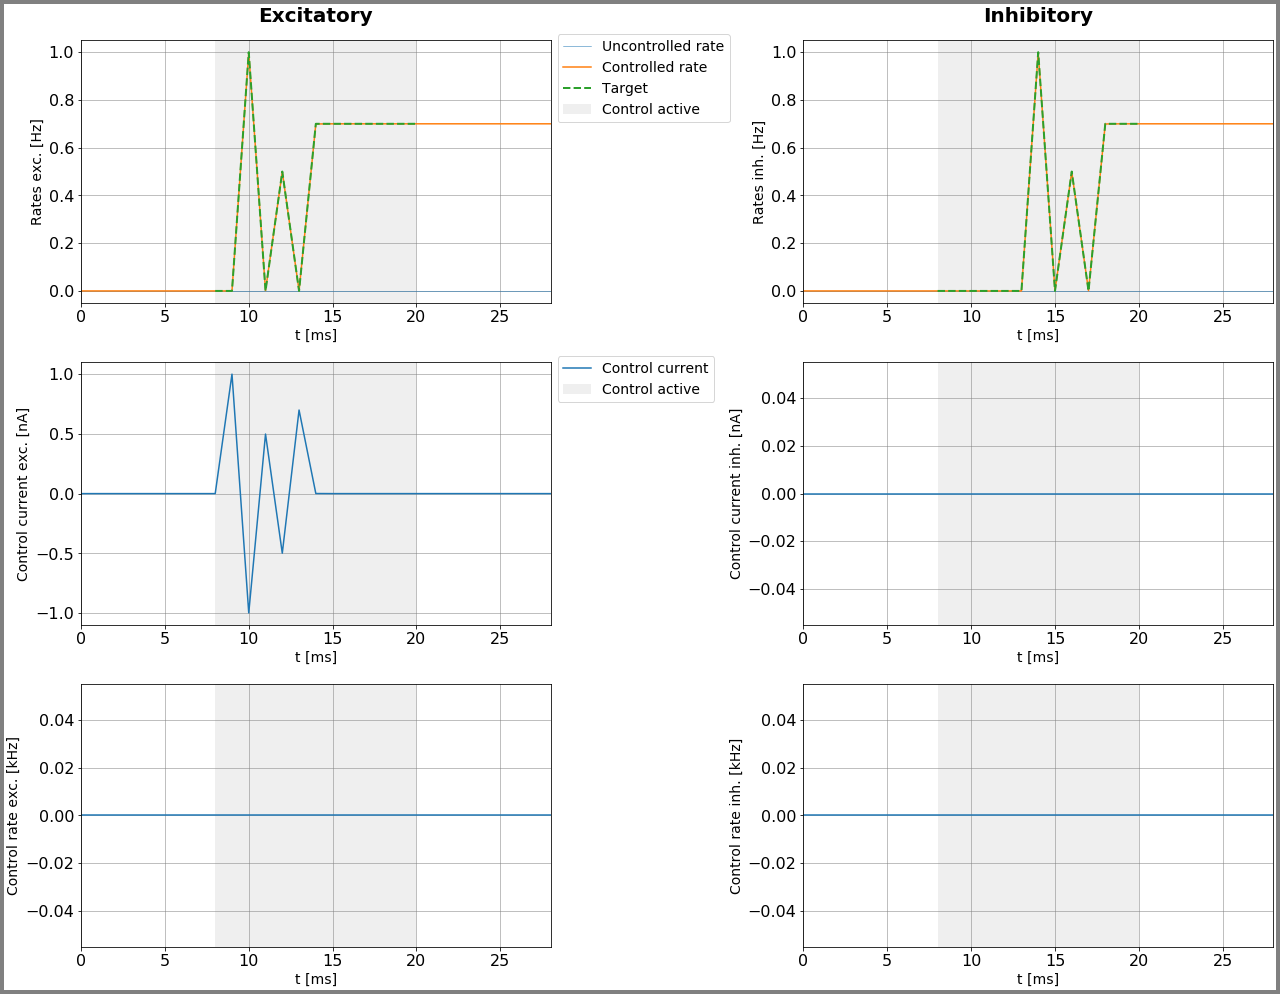

In [80]:
plotFunc.plot_control(aln, bestControlA, dur, dur_pre, dur_post, high_state_vars, target, path)

In [86]:
cost.setParams(costparams[0], costparams[1], costparams[2])
setinitvars(high_state_vars)
max_it = 100
start_step = 1.
alg = "A2"
case = "test"
incl_step = 10
test_step = 1e-6

aln.params.duration = dur
control3 = aln.getZeroControl()
#control4 = bestControlA_A2[:,:,n_pre-1:-n_pre+1]


print(max_cntrl, min_cntrl)

bestControlA_A2, bestStateA_A2, costA_A2, runtimeA_A2 = aln.A2(control3, target,
        max_iteration_ = max_it,  tolerance_ = tol, include_timestep_ = incl_step,
        start_step_ = start_step, test_step_ = test_step, max_control_ = max_cntrl,
        min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre,
        t_sim_post_ = dur_post, control_variables_ = control_ind, prec_variables_ = prec_var)

#0.003933378523157236

ERROR:root:not implemented for less than full timesteps


set cost params
1.0 -1.0
RUN  0 , total integrated cost:  0.00136
RUN  1 , total integrated cost:  0.0005530623722076417
RUN  2 , total integrated cost:  0.00044936871067183996
RUN  3 , total integrated cost:  0.0004277012781754202
RUN  4 , total integrated cost:  0.0004191314764336925
RUN  5 , total integrated cost:  0.00041755282506943645
RUN  6 , total integrated cost:  0.00041858942587726957
RUN  7 , total integrated cost:  0.0004217109068687648
RUN  8 , total integrated cost:  0.0004210672217629987
RUN  9 , total integrated cost:  0.00042071950397816455
RUN  10 , total integrated cost:  0.00042048372728892107
RUN  11 , total integrated cost:  0.00042033843691662086
RUN  12 , total integrated cost:  0.0004203842892348858
RUN  13 , total integrated cost:  0.00042038194935269184
RUN  14 , total integrated cost:  0.0004203819134389507
RUN  15 , total integrated cost:  0.0004203819130942231
RUN  16 , total integrated cost:  0.00042038191306729175
RUN  17 , total integrated cost:  0.000

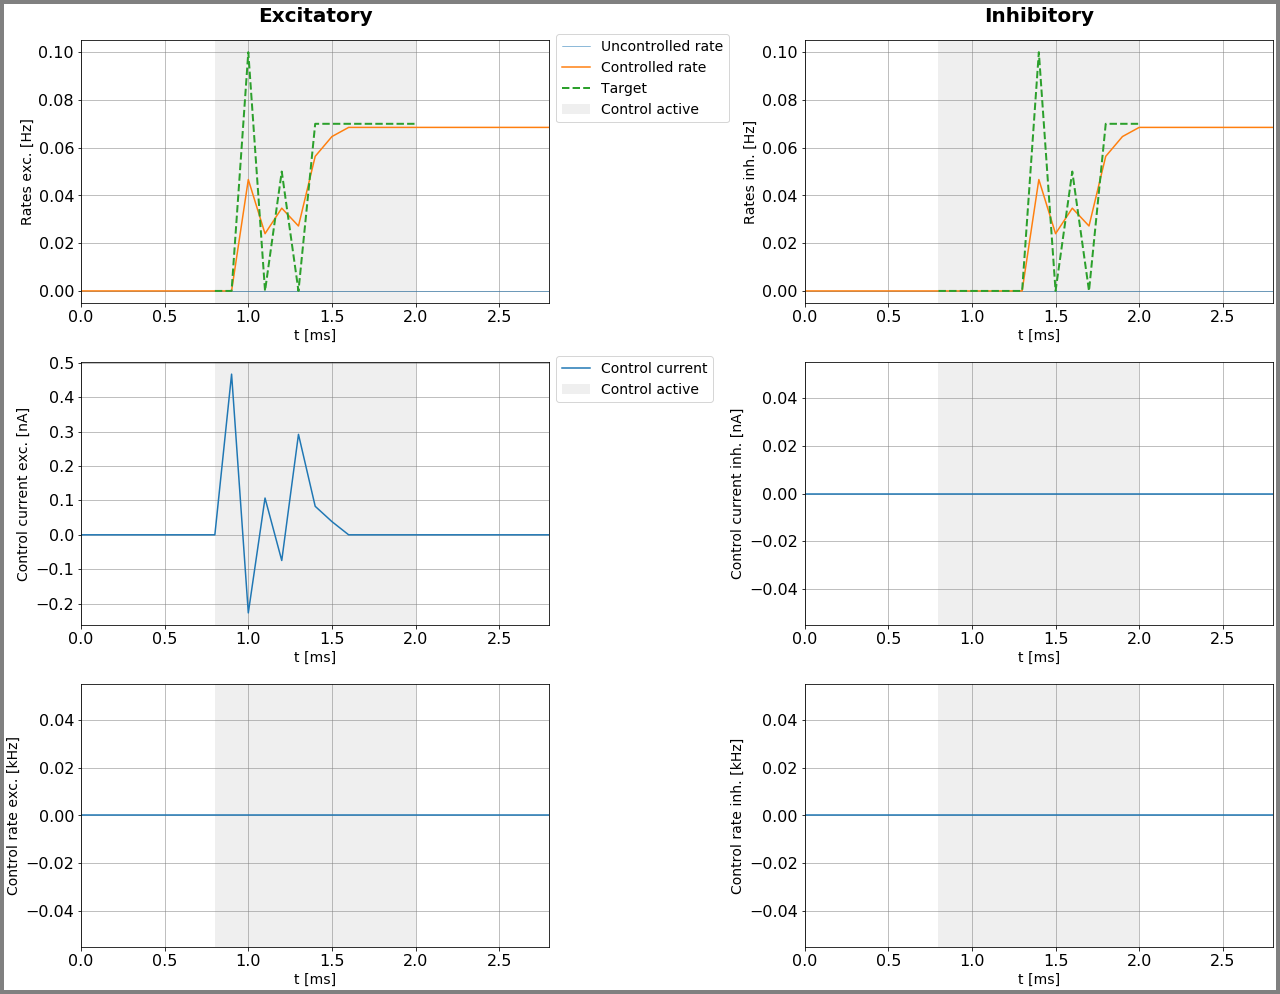

In [88]:
plotFunc.plot_control(aln, bestControlA_A2, dur, dur_pre, dur_post, high_state_vars, target, path)

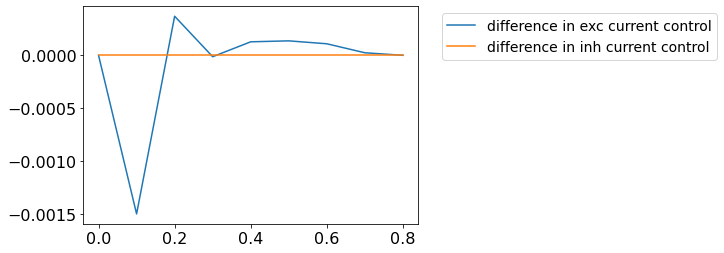

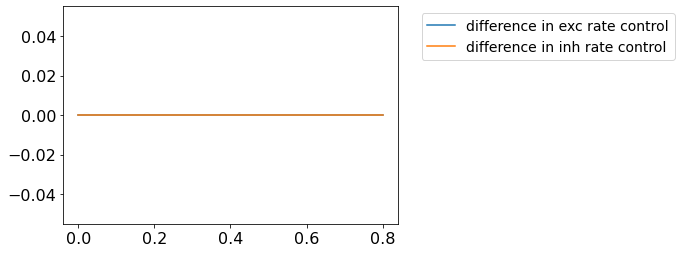

In [114]:
diff = bestControlA - bestControlA_A2
#diff[0,2,-2:] = 0.

#c_diff = costA_A2[6] - costA[3]
#print(c_diff)

t = np.arange(0,dur+0.1, 0.1)

plt.plot(t, diff[0,0,:], label="difference in exc current control")
plt.plot(t, diff[0,1,:], label="difference in inh current control")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()
plt.show()

plt.plot(t, diff[0,2,:], label="difference in exc rate control")
plt.plot(t, diff[0,3,:], label="difference in inh rate control")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()
plt.show()

### Testcases

1. PRECISION ONLY, NO DELAY
    - [x] 0 control, 0 precision measure, no delay
    - [x] 1 control, 1 precision measure, no delay
    - [x] 0 control, 1 precision measure, no delay
    - [x] 1 control, 0 precision measure, no delay
    - [] 2 control, 0 precision measure, no delay (slow to converge)
    - [] 2 control, 1 precision measure, no delay (slow to converge)

2. PRECISON + ENERGY + SPARSITY, NO DELAY
    - [x] 0 control, 0 precision measure, no delay
    - [x] 1 control, 1 precision measure, no delay
    - [] 0 control, 1 precision measure, no delay (requires different weights, gradient vanishes, A2 performes differently and worse)
    - [] 1 control, 0 precision measure, no delay (requires different weights, gradient vanishes, A2 performes differently and worse)
    - [x] 2 control, 0 precision measure, no delay
    - [] 2 control, 1 precision measure, no delay (requires different weights, zero control as output, gradient nonvanishing because on boundary. At higher weights, gradient vanishes)
    
3. PRECISION ONLY, DELAY
    - [x] 0 control, 0 precision measure, delay
    - [x] 1 control, 1 precision measure, delay
    - [] 0 control, 1 precision measure, delay (not in every case, could have several solutions)
    - [] 1 control, 0 precision measure, delay (not in every case, could have several solutions)
    - [x] 2 control, 0 precision measure, delay (sometimes slow convergence)
    - [x] 2 control, 1 precision measure, delay (sometimes slow to converge)

4. PRECISON + ENERGY + SPARSITY
    - [] 0 control, 0 precision measure, delay (gradient does not quite vanish)
    - [] 1 control, 1 precision measure, delay (gradient does not quite vanish)
    - [] 0 control, 1 precision measure, delay (requires different weights, gradient does not quite vanish, A2 performes differently and worse)
    - [] 1 control, 0 precision measure, delay (requires different weights, gradient does not quite vanish, A2 performes differently and worse)
    - [] 2 control, 0 precision measure, delay (gradient does not quite vanish)
    - [] 2 control, 1 precision measure, delay (requires different weights, gradient does not quite vanish, A2 performes differently and worse)
    
The cost functional should always have more than one minimum. If the "direct" control (0,0; 1,1; 2,0; 3,1) is not applied, it is much more likely to end up in a local minimum, because there is no "dominant" contribution.